# Single Layer Perceptron (SLP) — Klasifikasi Iris Setosa vs Iris Versicolor

Notebook ini adalah replikasi **PERSIS** dari perhitungan pada file Excel
`PMM-TemplateSLP_FILLED.xlsx` (sheet `Data`, `SLP-Training`, dan `SLP-Validation`).

## Arsitektur & aturan yang direplikasi dari file Excel

- **Input**: 4 fitur (X1 = Sepal Length, X2 = Sepal Width, X3 = Petal Length, X4 = Petal Width)
- **Target**: Iris-setosa = 0, Iris-versicolor = 1
- **Bobot awal**: bias = teta1 = teta2 = teta3 = teta4 = 0.5 (sel `I5:M5`)
- **Learning rate** (sel `K2`) = 0.1
- **Fungsi aktivasi**: Sigmoid → `g(z) = 1 / (1 + e^-z)`
- **Threshold prediksi**: `g(z) > 0.5` → kelas 1, selain itu → kelas 0
- **Fungsi error**: Sum Square Error (SSE) = `(g(z) - target)^2`
- **Gradient (delta)**: `d = 2 * (g(z) - target) * (1 - g(z)) * g(z)`
- **Update bobot**: `w_baru = w_lama - learning_rate * d` (Online/Stochastic Gradient Descent — diupdate setiap 1 baris data, bobot terus berlanjut antar-epoch tanpa direset)
- **Data latih** (sheet `SLP-Training`): 80 baris per epoch, yaitu baris data ke-1 s.d. 40 (Iris-setosa) dan ke-51 s.d. 90 (Iris-versicolor)
- **Data validasi** (sheet `SLP-Validation`): 20 baris, yaitu baris data ke-41 s.d. 50 (Iris-setosa) dan ke-91 s.d. 100 (Iris-versicolor)
- **Validasi per-epoch**: Setelah selesai training epoch N, bobot akhir epoch N digunakan untuk mengevaluasi 20 data validasi (tanpa update bobot)
- **Epoch**: 5 epoch, setiap epoch mengulang 80 baris data training yang sama secara berurutan.
- **Evaluasi**: MSE tiap epoch = `AVERAGE(SSE)`, Akurasi tiap epoch = `hits / n_samples`


## 0. Import Library

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import openpyxl

%matplotlib inline

## 1. Konfigurasi Model
Hyperparameter dan pengaturan awal, disamakan persis dengan sel-sel di sheet `SLP`.

In [2]:
@dataclass
class SLPConfig:
    """Konfigurasi hyperparameter, disamakan persis dengan sheet Excel."""

    learning_rate: float = 0.1          # sel K2
    n_epochs: int = 5                   # sel AB8
    initial_weights: np.ndarray = field(
        default_factory=lambda: np.array([0.5, 0.5, 0.5, 0.5, 0.5])
    )  # bias, teta1, teta2, teta3, teta4 (sel I5:M5)
    # baris data (1-based) untuk training: 1-40 (setosa) + 51-90 (versicolor)
    train_rows_1based: list[int] = field(
        default_factory=lambda: list(range(1, 41)) + list(range(51, 91))
    )
    # baris data (1-based) untuk validasi: 41-50 (setosa) + 91-100 (versicolor)
    # sesuai sheet SLP-Validation di file Excel
    val_rows_1based: list[int] = field(
        default_factory=lambda: list(range(41, 51)) + list(range(91, 101))
    )


## 2. Memuat Data dari Sheet `Data` pada File Excel

Struktur sheet `Data` (tanpa header):

| Kolom | Isi |
|---|---|
| A | Sepal Length (X1) |
| B | Sepal Width (X2) |
| C | Petal Length (X3) |
| D | Petal Width (X4) |
| E | Label kelas (`Iris-setosa` / `Iris-versicolor`) |


In [3]:
def load_iris_data_from_excel(excel_path: str | Path, sheet_name: str = "Data"):
    """
    Membaca data mentah dari sheet "Data" pada file Excel.

    Return
    ------
    X : np.ndarray, shape (n_samples, 4)
    y : np.ndarray, shape (n_samples,)      -> 0 = setosa, 1 = versicolor
    """
    wb = openpyxl.load_workbook(excel_path, data_only=False)
    ws = wb[sheet_name]

    X_rows, y_rows = [], []
    for row in ws.iter_rows(min_row=1, values_only=True):
        x1, x2, x3, x4, label = row[:5]
        if x1 is None:
            continue
        target = 0 if label == "Iris-setosa" else 1
        X_rows.append([x1, x2, x3, x4])
        y_rows.append(target)

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=int)


def build_training_set(X_all: np.ndarray, y_all: np.ndarray, cfg: SLPConfig):
    """Ambil subset baris training sesuai pola kolom 'No' di sheet SLP-Training."""
    idx0 = [r - 1 for r in cfg.train_rows_1based]  # konversi ke 0-based
    return X_all[idx0], y_all[idx0]


def build_validation_set(X_all: np.ndarray, y_all: np.ndarray, cfg: SLPConfig):
    """Ambil subset baris validasi sesuai sheet SLP-Validation di file Excel.
    
    Baris 41-50 (Iris-setosa) dan 91-100 (Iris-versicolor) = 20 baris total.
    """
    idx0 = [r - 1 for r in cfg.val_rows_1based]  # konversi ke 0-based
    return X_all[idx0], y_all[idx0]


## 3. Fungsi-Fungsi Inti Perceptron

Identik dengan rumus tiap kolom di sheet `SLP` (kolom N, O, P, Q, R, T, U, V, W, X).

In [4]:
def sigmoid(z: float) -> float:
    """Kolom O -> g(z) = 1 / (1 + EXP(-z))"""
    return 1.0 / (1.0 + np.exp(-z))


def forward_pass(x: np.ndarray, w: np.ndarray):
    """
    Satu langkah forward untuk satu baris data.

    z (kolom N)    = bias + teta1*x1 + teta2*x2 + teta3*x3 + teta4*x4
    g(z) (kolom O) = sigmoid(z)
    pred (kolom P) = 1 jika g(z) > 0.5, else 0
    """
    z = w[0] + np.dot(w[1:], x)
    o = sigmoid(z)
    pred = 1 if o > 0.5 else 0
    return z, o, pred


def compute_gradient(o: float, target: int, x: np.ndarray) -> np.ndarray:
    """
    Kolom T,U,V,W,X -> gradient/delta untuk bias & tiap bobot.

        d_bias   = 2 * (o - target) * (1 - o) * o
        d_teta_i = d_bias * x_i
    """
    d_bias = 2 * (o - target) * (1 - o) * o
    d_weights = d_bias * x
    return np.concatenate(([d_bias], d_weights))


def update_weights(w: np.ndarray, grad: np.ndarray, lr: float) -> np.ndarray:
    """Kolom I,J,K,L,M baris berikutnya -> w_baru = w_lama - lr * gradient"""
    return w - lr * grad

## 4. Loop Training

Melatih perceptron secara online (update bobot setiap 1 baris data), berjalan berurutan
sebanyak `cfg.n_epochs` kali melewati seluruh data training, **persis** seperti alur
baris 5 s.d. 404 di sheet `SLP` (bobot tidak direset di antar-epoch).

In [5]:
@dataclass
class EpochResult:
    epoch: int
    mse: float
    accuracy: float
    val_mse: float = 0.0        # MSE pada data validasi (sheet SLP-Validation)
    val_accuracy: float = 0.0   # Akurasi pada data validasi


def train_slp(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    cfg: SLPConfig,
):
    """
    Melatih SLP dan mengevaluasi validasi per-epoch.

    Alur setiap epoch:
    1. Training: forward pass + update bobot setelah tiap baris (online SGD)
    2. Validasi: evaluasi 20 baris validasi dengan bobot AKHIR epoch ini (no update)
       → identik dengan sheet SLP-Validation di file Excel

    Return
    ------
    weights_final   : np.ndarray        -> bobot akhir setelah semua epoch
    history         : list[EpochResult] -> MSE & akurasi training + validasi tiap epoch
    predictions_log : list[dict]        -> log lengkap tiap baris training (untuk audit)
    """
    w = cfg.initial_weights.copy()
    n_samples = len(X_train)

    history: list[EpochResult] = []
    predictions_log: list[dict] = []

    for epoch in range(1, cfg.n_epochs + 1):
        # ── Training loop ──────────────────────────────────────────────────
        sse_list = []
        hit_list = []

        for i in range(n_samples):
            x = X_train[i]
            target = y_train[i]

            # forward pass (kolom N, O, P)
            z, o, pred = forward_pass(x, w)

            # error & sum square error (kolom Q, R)
            error = o - target
            sse = error ** 2

            hit = 1 if pred == target else 0
            sse_list.append(sse)
            hit_list.append(hit)
            predictions_log.append(
                dict(epoch=epoch, sample=i + 1, z=z, g_z=o, pred=pred,
                     target=int(target), error=error, sse=sse, hit=hit)
            )

            # gradient (kolom T,U,V,W,X) lalu update bobot
            grad = compute_gradient(o, target, x)
            w = update_weights(w, grad, cfg.learning_rate)

        mse = float(np.mean(sse_list))
        acc = float(np.mean(hit_list))

        # ── Validasi per-epoch ─────────────────────────────────────────────
        # Gunakan bobot AKHIR epoch ini (w setelah update terakhir),
        # sama persis dengan bobot di kolom I-M sheet SLP-Validation
        val_sse_list = []
        val_hit_list = []
        for j in range(len(X_val)):
            x_v = X_val[j]
            t_v = y_val[j]
            _, o_v, pred_v = forward_pass(x_v, w)  # NO weight update
            val_sse_list.append((o_v - t_v) ** 2)
            val_hit_list.append(1 if pred_v == t_v else 0)

        val_mse = float(np.mean(val_sse_list))
        val_acc = float(np.mean(val_hit_list))

        history.append(EpochResult(
            epoch=epoch,
            mse=mse,
            accuracy=acc,
            val_mse=val_mse,
            val_accuracy=val_acc,
        ))

    return w, history, predictions_log


## 5. Validasi Per-Epoch (Sheet `SLP-Validation`)

Baris 41-50 (Iris-setosa) dan 91-100 (Iris-versicolor) = 20 baris data validasi.
Setelah setiap epoch selesai training, bobot akhir digunakan untuk mengevaluasi
20 baris ini tanpa melakukan update bobot — persis seperti sheet `SLP-Validation`.


In [6]:
def predict(X: np.ndarray, w: np.ndarray) -> np.ndarray:
    """Prediksi kelas (0/1) untuk sekumpulan data."""
    z = w[0] + X @ w[1:]
    o = sigmoid(z)
    return (o > 0.5).astype(int)


## 6. Visualisasi

Dua grafik dengan **2 garis masing-masing** (Training + Validasi),
menyerupai Chart 1 (Loss Function MSE) dan Chart 2 (Akurasi) di sheet `Grafik` file Excel.


In [7]:
def plot_training_curves(history: list[EpochResult], save_path: str | Path | None = None):
    """Membuat grafik MSE per epoch dan Akurasi per epoch dengan 2 garis: Training + Validasi."""
    import matplotlib.pyplot as plt

    epochs       = [h.epoch        for h in history]
    mse_train    = [h.mse          for h in history]
    mse_val      = [h.val_mse      for h in history]
    acc_train    = [h.accuracy     for h in history]
    acc_val      = [h.val_accuracy for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ── Grafik 1: Loss (MSE) per Epoch ──────────────────────────────────
    axes[0].plot(epochs, mse_train, marker='o', color='#2E75B6', linewidth=2,
                 label='Training')
    axes[0].plot(epochs, mse_val,   marker='s', color='#FF0000', linewidth=2,
                 label='Validasi')
    axes[0].set_title('1. Loss Function (MSE) per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Mean Square Error')
    axes[0].set_xticks(epochs)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Grafik 2: Akurasi per Epoch ──────────────────────────────────────
    axes[1].plot(epochs, acc_train, marker='o', color='#375623', linewidth=2,
                 label='Training')
    axes[1].plot(epochs, acc_val,   marker='^', color='#FF8000', linewidth=2,
                 label='Validasi')
    axes[1].set_title('2. Akurasi per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Akurasi')
    axes[1].set_xticks(epochs)
    axes[1].set_ylim(0, 1.2)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f'Grafik disimpan ke: {save_path}')
    plt.show()


## 7. Eksekusi Program

Ubah nilai `EXCEL_PATH` di bawah ini jika nama/lokasi file Excel Anda berbeda.

In [8]:
EXCEL_PATH = "PMM-TemplateSLP_FILLED.xlsx"  # <-- ganti path jika perlu

cfg = SLPConfig()

# 1) Muat seluruh data (100 baris) dari sheet "Data"
X_all, y_all = load_iris_data_from_excel(EXCEL_PATH)
print(f"Total data dimuat dari sheet 'Data': {len(X_all)} baris")

# 2) Ambil subset training (80 baris)
X_train, y_train = build_training_set(X_all, y_all, cfg)
print(f"Jumlah data training per epoch      : {len(X_train)} baris (baris 1-40 & 51-90)")

# 3) Ambil subset validasi (20 baris)
X_val, y_val = build_validation_set(X_all, y_all, cfg)
print(f"Jumlah data validasi per epoch      : {len(X_val)} baris (baris 41-50 & 91-100)")

print(f"Learning rate                       : {cfg.learning_rate}")
print(f"Jumlah epoch                        : {cfg.n_epochs}")
print(f"Bobot awal (bias,t1,t2,t3,t4)       : {cfg.initial_weights.tolist()}")


Total data dimuat dari sheet 'Data': 100 baris
Jumlah data training per epoch      : 80 baris (baris 1-40 & 51-90)
Jumlah data validasi per epoch      : 20 baris (baris 41-50 & 91-100)
Learning rate                       : 0.1
Jumlah epoch                        : 5
Bobot awal (bias,t1,t2,t3,t4)       : [0.5, 0.5, 0.5, 0.5, 0.5]


In [9]:
# 4) Latih model (training + validasi per-epoch)
w_final, history, predictions_log = train_slp(X_train, y_train, X_val, y_val, cfg)

# 5) Tampilkan ringkasan tiap epoch (sesuai tabel di sheet Grafik file Excel)
print(f"{'Epoch':>6} | {'MSE Train':>12} | {'Acc Train':>10} | {'MSE Val':>10} | {'Acc Val':>10}")
print("-" * 60)
for h in history:
    print(f"{h.epoch:>6} | {h.mse:>12.6f} | {h.accuracy:>10.4f} | {h.val_mse:>10.6f} | {h.val_accuracy:>10.4f}")


 Epoch |    MSE Train |  Acc Train |    MSE Val |    Acc Val
------------------------------------------------------------
     1 |     0.449889 |     0.5250 |   0.328951 |     0.5000
     2 |     0.037452 |     0.9500 |   0.247289 |     0.5000
     3 |     0.024372 |     0.9750 |   0.175892 |     0.5000
     4 |     0.017357 |     0.9750 |   0.119381 |     0.8500
     5 |     0.012740 |     0.9875 |   0.081581 |     1.0000


In [10]:
# 6) Bobot akhir setelah training
print("Bobot akhir setelah training:")
names = ["bias", "teta1", "teta2", "teta3", "teta4"]
for name, val in zip(names, w_final):
    print(f"  {name:<6}: {val: .6f}")


Bobot akhir setelah training:
  bias  :  0.257720
  teta1 : -0.241802
  teta2 : -0.416903
  teta3 :  1.122214
  teta4 :  0.824059


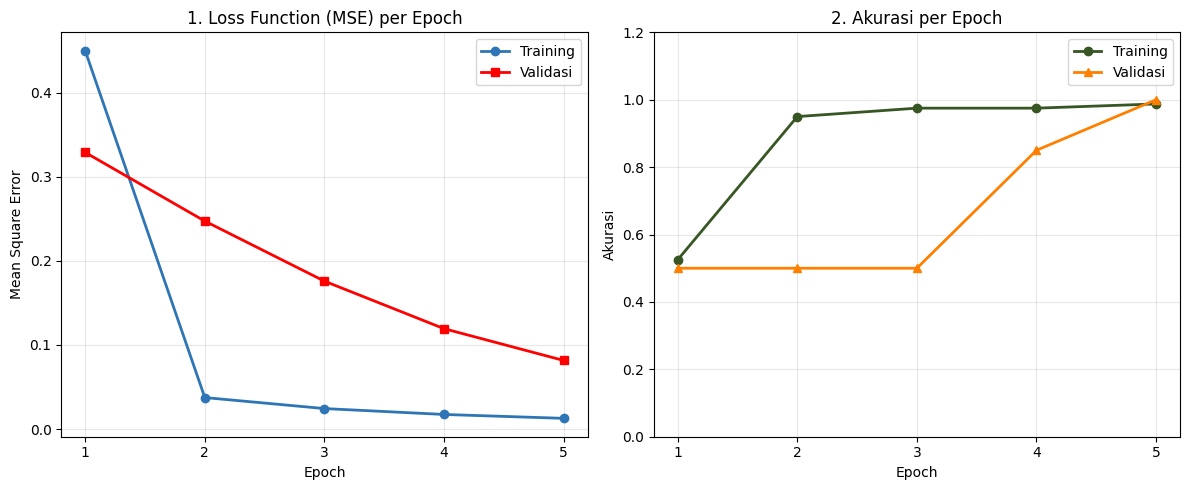

In [11]:
# 7) Grafik Loss (MSE) & Akurasi per Epoch — Training vs Validasi
plot_training_curves(history)


## 8. (Opsional) Tabel Ringkasan MSE & Akurasi per Epoch (Pandas DataFrame)

In [12]:
import pandas as pd

df_history = pd.DataFrame([{
    'Epoch'         : h.epoch,
    'MSE Training'  : h.mse,
    'Acc Training'  : h.accuracy,
    'MSE Validasi'  : h.val_mse,
    'Acc Validasi'  : h.val_accuracy,
} for h in history])
df_history


,Epoch,MSE Training,Acc Training,MSE Validasi,Acc Validasi
0,1,0.449889,0.5250,0.328951,0.50
1,2,0.037452,0.9500,0.247289,0.50
2,3,0.024372,0.9750,0.175892,0.50
3,4,0.017357,0.9750,0.119381,0.85
4,5,0.012740,0.9875,0.081581,1.00
